<a href="https://colab.research.google.com/github/MY-Wayy/DeepLearning_Lecture/blob/main/%EC%8B%AC%EC%B8%B5%ED%95%99%EC%8A%B5_7%EC%A3%BC%EC%B0%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 14장. 모델 성능 향상 시키기

In [ ]:
import pandas as pd
!git clone https://github.com/taehojo/data.git

fatal: destination path 'data' already exists and is not an empty directory.


In [ ]:
df_pre = pd.read_csv('./data/wine.csv')
df = df_pre.sample(frac=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6496 entries, 6384 to 5932
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   7.4     6496 non-null   float64
 1   0.7     6496 non-null   float64
 2   0       6496 non-null   float64
 3   1.9     6496 non-null   float64
 4   0.076   6496 non-null   float64
 5   11      6496 non-null   float64
 6   34      6496 non-null   float64
 7   0.9978  6496 non-null   float64
 8   3.51    6496 non-null   float64
 9   0.56    6496 non-null   float64
 10  9.4     6496 non-null   float64
 11  5       6496 non-null   int64  
 12  1       6496 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 710.5 KB


In [ ]:
df.describe()

,7.4,0.7,0,1.9,0.076,11,34,0.9978,3.51,0.56,9.4,5,1
count,6496.000000,6496.000000,6496.000000,6496.000000,6496.000000,6496.000000,6496.000000,6496.000000,6496.000000,6496.000000,6496.000000,6496.000000,6496.000000
mean,7.215279,0.339611,0.318682,5.443781,0.056031,30.528325,115.757158,0.994696,3.218456,0.531264,10.491969,5.818504,0.245998
std,1.296532,0.164588,0.145275,4.757967,0.035035,17.749112,56.517103,0.002999,0.160759,0.148817,1.192727,0.873263,0.430710
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.375000,0.992340,3.110000,0.430000,9.500000,5.000000,0.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,0.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,0.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


In [ ]:
from sklearn.model_selection import train_test_split

X = df.iloc[:, 0:12]
y = df.iloc[:, 12]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5196, 12), (1300, 12), (5196,), (1300,))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 모델 설정
model = Sequential()
model.add(Dense(30, input_dim=12, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 30)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 12)             │           372 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 875 (3.42 KB)

 Trainable params: 875 (3.42 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 모델 컴파일
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

modelpath = '/data/model/Ch14-wine-bestmodel.keras'

checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss', save_best_only=True)
earlyStoppingCallback = EarlyStopping(monitor='val_loss', patience=10)

In [ ]:
history = model.fit(X_train, y_train,
                    epochs=200, validation_split=0.2,
                    batch_size=500,
                    callbacks=[earlyStoppingCallback, checkpointer])

Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.7613 - loss: 0.5835 - val_accuracy: 0.7202 - val_loss: 0.5021
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7613 - loss: 0.4081 - val_accuracy: 0.7202 - val_loss: 0.4277
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7613 - loss: 0.3851 - val_accuracy: 0.7202 - val_loss: 0.4097
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7613 - loss: 0.3669 - val_accuracy: 0.7202 - val_loss: 0.4014
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7618 - loss: 0.3531 - val_accuracy: 0.7269 - val_loss: 0.3751
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7890 - loss: 0.3394 - val_accuracy: 0.7760 - val_loss: 0.3619
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8253 - loss: 0.3292 - val_accuracy: 0.8067 - val_loss: 0.3525
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8496 - loss: 0.3182 - val_accuracy: 0.8529 - val_loss:

In [ ]:
score = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {score[1]:.4f}')

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9669 - loss: 0.1008
Test Accuracy: 0.9669


In [ ]:
hist_df = pd.DataFrame(history.history)
hist_df

,accuracy,loss,val_accuracy,val_loss
0,0.761309,0.583505,0.720192,0.502150
1,0.761309,0.408104,0.720192,0.427668
2,0.761309,0.385071,0.720192,0.409711
3,0.761309,0.366865,0.720192,0.401371
4,0.761790,0.353142,0.726923,0.375079
...,...,...,...,...
117,0.974013,0.079934,0.970192,0.111130
118,0.975698,0.079516,0.969231,0.114256
119,0.974254,0.080078,0.972115,0.110490
120,0.974735,0.081966,0.971154,0.113457


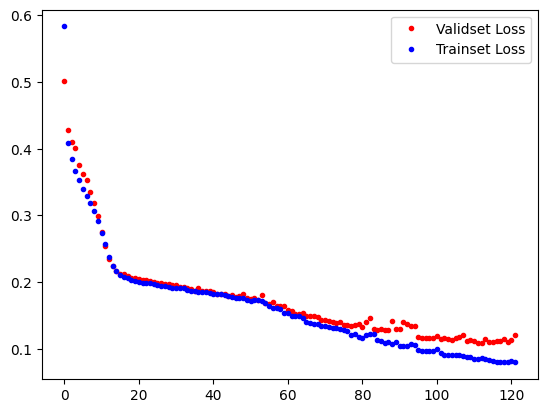

In [ ]:
y_vloss = hist_df['val_loss']
y_loss = hist_df['loss']

import numpy as np
import matplotlib.pyplot as plt

x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, 'o', c='red', markersize=3, label='Validset Loss')
plt.plot(x_len, y_loss, 'o', c='blue', markersize=3, label='Trainset Loss')
plt.legend()
plt.show()

<br>
<br>

# 15장. 실제 데이터로 만들어보는 모델

In [ ]:
!git clone https://github.com/taehojo/data.git

fatal: destination path 'data' already exists and is not an empty directory.


In [ ]:
import pandas as pd

df2 = pd.read_csv('/content/data/house_train.csv')
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
df2.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [ ]:
# Convert categorical features to numerical using one-hot encoding
df2_encoded = pd.get_dummies(df, drop_first=True)

df2_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 246 entries, Id to SaleCondition_Partial
dtypes: bool(208), float64(3), int64(35)
memory usage: 730.1 KB


In [ ]:
display(df2_encoded.head())

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


In [ ]:
df2_encoded.isnull().sum().sort_values(ascending=False)

,0
LotFrontage,259
GarageYrBlt,81
MasVnrArea,8
MSSubClass,0
OverallQual,0
...,...
SaleCondition_AdjLand,0
SaleCondition_Alloca,0
SaleCondition_Family,0
SaleCondition_Normal,0


In [ ]:
df2_encoded = df_encoded.fillna(df_encoded.mean())

df2_encoded.isnull().sum().sort_values(ascending=False)

,0
Id,0
MSSubClass,0
LotFrontage,0
LotArea,0
OverallQual,0
...,...
SaleCondition_AdjLand,0
SaleCondition_Alloca,0
SaleCondition_Family,0
SaleCondition_Normal,0


In [ ]:
# 상관관계 계산
correlations = df2_encoded.corr()['SalePrice'].sort_values(ascending=False)

# 상관관계가 낮은(절대값 0.1 미만) 속성 추출
low_corr_features = correlations[abs(correlations) < 0.1].index

# 타겟 변수(SalePrice)와 상관관계가 낮은 특성, 그리고 Id 제거
X = df2_encoded.drop(['SalePrice', 'Id'] + list(low_corr_features), axis=1)
y = df2_encoded['SalePrice']

print("제거된 속성 개수:", len(low_corr_features))
print("X shape:", X.shape)
print("y shape:", y.shape)

제거된 속성 개수: 136
X shape: (1460, 109)
y shape: (1460,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 모델 설정
model = Sequential()
model.add(Dense(64, input_dim=X.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1)) # 회귀 모델이므로 활성화 함수 없음

# 모델 컴파일 (metrics 추가)
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 64)             │         7,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,665 (37.75 KB)

 Trainable params: 9,665 (37.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# 조기 종료 조건 설정
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=20)

# 모델 학습
history = model.fit(X, y, epochs=2000, batch_size=32, validation_split=0.25, callbacks=[early_stopping_callback])

Epoch 1/2000
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 38437224448.0000 - mae: 179373.2031 - val_loss: 36566937600.0000 - val_mae: 174678.4375
Epoch 2/2000
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 34742267904.0000 - mae: 169445.4062 - val_loss: 29756717056.0000 - val_mae: 155204.0000
Epoch 3/2000
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 22917670912.0000 - mae: 131528.1875 - val_loss: 13083914240.0000 - val_mae: 92954.8281
Epoch 4/2000
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9731670016.0000 - mae: 65856.3438 - val_loss: 5398247936.0000 - val_mae: 45947.1328
Epoch 5/2000
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7429908480.0000 - mae: 48202.1445 - val_loss: 4787269632.0000 - val_mae: 42738.0586
Epoch 6/2000
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6392572928.0000 - mae: 45806.7148 - val_loss: 4485116416.0000 - val_mae: 41603.3633
Epoch 7/2000
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5597266944.0000 - mae: 44296.0625 - val_loss: 4240098816.0000 - 

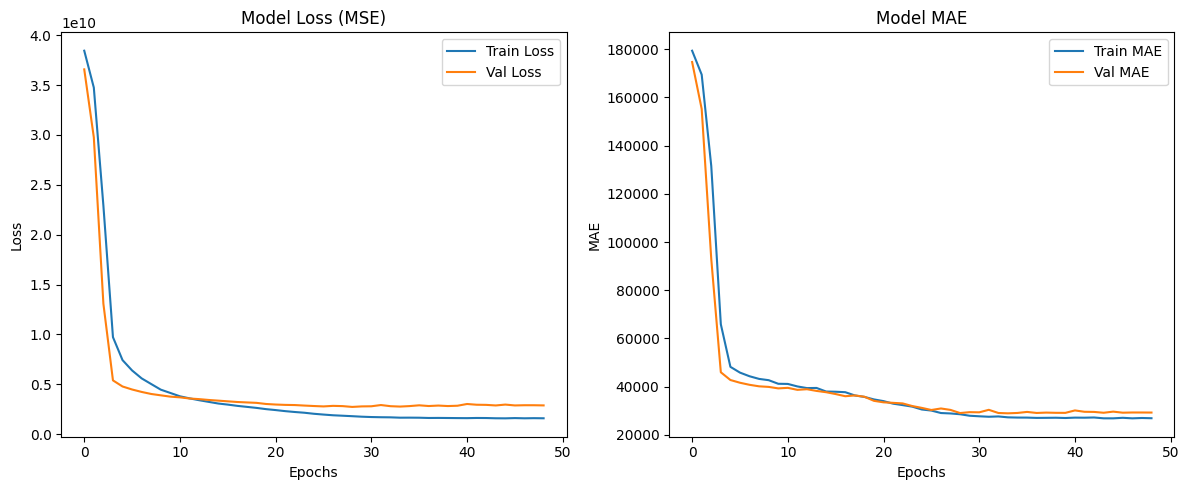

In [ ]:
import matplotlib.pyplot as plt

# 학습 이력 데이터프레임 생성
hist_df = pd.DataFrame(history.history)

# 시각화 설정
plt.figure(figsize=(12, 5))

# 1. Loss (MSE) 시각화
plt.subplot(1, 2, 1)
plt.plot(hist_df['loss'], label='Train Loss')
plt.plot(hist_df['val_loss'], label='Val Loss')
plt.title('Model Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# 2. MAE 시각화
plt.subplot(1, 2, 2)
plt.plot(hist_df['mae'], label='Train MAE')
plt.plot(hist_df['val_mae'], label='Val MAE')
plt.title('Model MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import r2_score

# 전체 데이터 X에 대한 예측값 계산
y_pred = model.predict(X)

# 결정 계수(R-squared) 계산
r2 = r2_score(y, y_pred)

print(f"모델의 결정 계수 (R2 Score): {r2:.4f}")
print(f"이 수치는 모델이 전체 데이터 변동성의 {r2*100:.2f}%를 설명함을 의미합니다.")

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
모델의 결정 계수 (R2 Score): 0.6966
이 수치는 모델이 전체 데이터 변동성의 69.66%를 설명함을 의미합니다.
